In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import numpy as np
import datetime
import time
import pickle
import os
import seaborn as sns
from scipy.interpolate import make_interp_spline
from tabulate import tabulate

import sys
sys.path.append("src")

from data_generation import *
from neural_networks import *
from estimation import *

pd.options.mode.chained_assignment = None
os.chdir('Result_Tables/')

## data generation 

In [136]:
## set up 
J = 10
M = 100
K = 1
np.random.seed(102666)

b1 = [1,1, -1]
b2 = [1,1, -3]
sigma1 = [1, 1, 1/3]
sigma2 = [1, 1, 1]
pi = 0.5 

params = [ b1, b2, sigma1, sigma2, pi ] 

dg = rcl_mix
delta = 0.1
seed = 102666

In [210]:
data = data_generation_fix1(params, J, K, M, seed, dg)
data_train, data_test = split_train_test(data, p = 1)

In [165]:
original_price = data_train['X']['price']

## train models

In [166]:
m1_deep, loss_deep = train_deep(data_train)
m1_mnl, losses_mnl = train_logit(data_train)
m1_rcl, losses_mnl = train_rcl(data_train)

## get the best response for the first product

In [184]:
price_range = np.arange(1, 500) / 100
results = []
cost = 1
for price in price_range:
    # update price
    data_train['X'].loc[rows, 'price'] = price
    # predict values
    deep_values = pred_deep(data_train, m1_deep)
    true_values = rcl_regenerate(data_train['X'], data_train, N=10000)
    mnl_values = pred_logit2(data_train, m1_mnl)
    rcl_values = pred_rcl(data_train, m1_rcl)
    # calculate profit
    profit_deep = deep_values[rows] * (data_train['X']['price'].loc[rows] - cost)
    profit_true = true_values[rows] * (data_train['X']['price'].loc[rows] - cost)
    profit_mnl = mnl_values[rows] * (data_train['X']['price'].loc[rows] - cost)
    profit_rcl = rcl_values[rows] * (data_train['X']['price'].loc[rows] - cost)
    
    result = {
        'price': price,
        'profit_deep': profit_deep,
        'profit_true': profit_true,
        'profit_mnl': profit_mnl,
        'profit_rcl': profit_rcl
    }
    results.append(result)
    

In [185]:
profit_deep_df = pd.DataFrame({
    res['price']: res['profit_deep'] for res in results
})
profit_true_df = pd.DataFrame({
    res['price']: res['profit_true'] for res in results
})

profit_mnl_df = pd.DataFrame({
    res['price']: res['profit_mnl'] for res in results
})

profit_rcl_df = pd.DataFrame({
    res['price']: res['profit_rcl'] for res in results
})
    

best_prices_deep = profit_deep_df.idxmax(axis=1) 
best_prices_true = profit_true_df.idxmax(axis=1) 
best_prices_mnl = profit_mnl_df.idxmax(axis=1) 
best_prices_rcl = profit_rcl_df.idxmax(axis=1) 

In [186]:
summary = pd.DataFrame({
    'best_price_deep': best_prices_deep,
    'best_price_true': best_prices_true,
    'best_price_mnl': best_prices_mnl,
    'best_price_rcl': best_prices_rcl})

In [188]:
summary

,best_price_deep,best_price_true,best_price_mnl,best_price_rcl
0,1.75,1.98,1.75,4.99
10,2.06,2.12,1.76,4.99
20,1.90,1.96,1.79,4.99
30,2.02,2.04,1.77,4.99
40,2.00,1.91,1.80,1.78
...,...,...,...,...
950,2.03,2.06,1.79,4.99
960,4.99,2.24,1.76,4.99
970,2.05,1.96,1.81,1.84
980,1.80,1.93,1.77,4.99


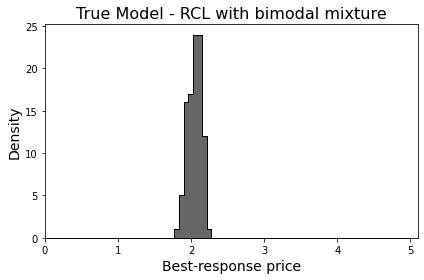

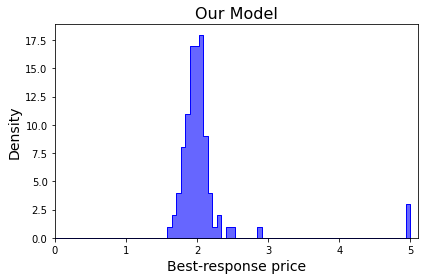

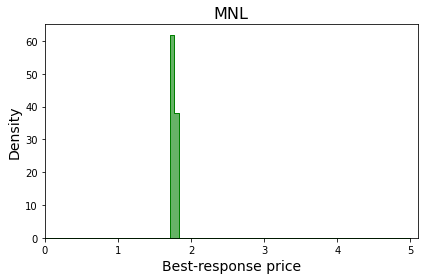

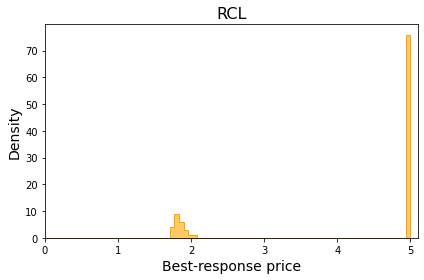

In [214]:
cols = ['best_price_true', 'best_price_deep', 'best_price_mnl', 'best_price_rcl']
titles = ['True Model - RCL with bimodal mixture', 'Our Model', 'MNL', 'RCL']
colors = ['black', 'blue', 'green', 'orange']

# Save individual plots
for i, col in enumerate(cols):
    plt.figure(figsize=(6, 4))
    sns.histplot(
        summary[col],
        element="step",
        bins=np.linspace(0, 5, 80),
        color=colors[i],
        alpha=0.6
    )
    plt.title(titles[i], fontsize=16)
    plt.xlabel('Best-response price', fontsize=14)
    plt.ylabel('Density', fontsize=14)
    plt.xlim(0, 5.1)
    plt.tight_layout()

    # Save the figure
    filename = f"price_distribution_{col}.png"
    plt.savefig(filename, dpi=300)
    plt.show()
    plt.close()